/tmp/ipykernel_3925781/270886586.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location='cpu')


✅ Successfully loaded CBMVAE from checkpoint.
Loading metadata from /home/oueslatiy/CBMC/CBMC/datasets/shapes3d_extracted/metadata.csv
Input Shape: torch.Size([64, 3, 64, 64])
Output Shape: torch.Size([64, 3, 64, 64])


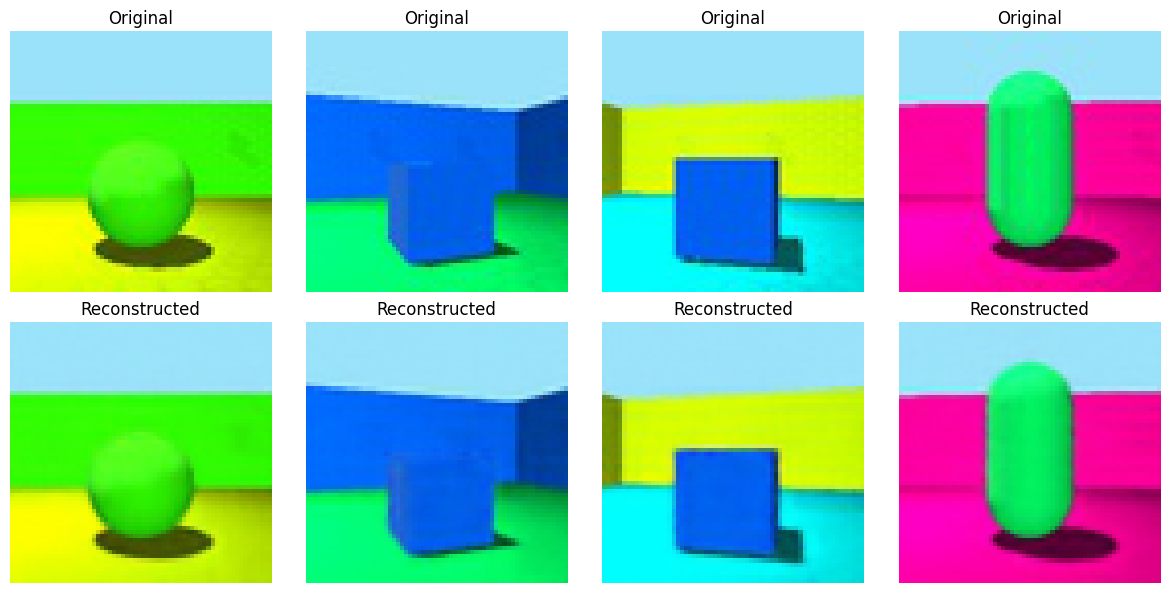

In [1]:
import os
import sys
import yaml
import torch
import importlib.util
from pathlib import Path
import matplotlib.pyplot as plt

# ==========================================
# 1. Path & Import Setup (The "Nuclear" Option)
# ==========================================
project_root = '/home/oueslatiy/CBMC/CBMC/PyTorchVAE'
datasets_root = '/home/oueslatiy/CBMC/CBMC/'

# Force import models.__init__ directly from the file to avoid location errors
init_path = os.path.join(project_root, 'models', '__init__.py')
spec = importlib.util.spec_from_file_location("models", init_path)
models_module = importlib.util.module_from_spec(spec)
sys.modules["models"] = models_module
spec.loader.exec_module(models_module)

# Now grab the dictionary and the Dataset class
vae_models = models_module.vae_models

# Ensure datasets is also discoverable
if project_root not in sys.path:
    sys.path.insert(0, project_root)

sys.path.append(datasets_root)
from datasets import VAEDataset

# ==========================================
# 2. Configuration & Paths
# ==========================================
config_path = os.path.join(project_root, 'configs/CBMVAE.yaml')
checkpoint_path = os.path.join(project_root, '/home/oueslatiy/CBMC/CBMC/PyTorchVAE/logs/CBMVAE/version_35/checkpoints/epoch=20-step=126000.ckpt')

with open(config_path, 'r') as file:
    config = yaml.safe_load(file)

# ==========================================
# 3. Initialize & Load Model
# ==========================================
model_name = config['model_params']['name']
model = vae_models[model_name](**config['model_params'])

checkpoint = torch.load(checkpoint_path, map_location='cpu')
state_dict = checkpoint['state_dict']

# RENAME KEYS: Fix the 'model.' prefix and the 'cem_cem' mismatch
new_state_dict = {}
for k, v in state_dict.items():
    # Remove Lightning wrapper prefix
    name = k.replace('model.', '')
    
    # Fix CBM naming: Change cem_cem_ to cem_model.cem_ to match class structure
    if name.startswith('cem_cem_'):
        name = name.replace('cem_cem_', 'cem_model.cem_')
    
    new_state_dict[name] = v

model.load_state_dict(new_state_dict)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print(f"✅ Successfully loaded {model_name} from checkpoint.")

# ==========================================
# 4. Load Data
# ==========================================
data = VAEDataset(**config["data_params"])
data.setup()
test_loader = data.test_dataloader()

# ==========================================
# 5. Run Manual Inference
# ==========================================
with torch.no_grad():
    # Get a real batch
    batch = next(iter(test_loader))
    real_imgs, labels = batch
    real_imgs = real_imgs.to(device)
    labels = labels.to(device)

    # Forward pass
    # Expected output for CBMVAE usually includes: [reconstruction, mu, log_var, concepts]
    results = model(real_imgs, interventions=labels)
    recons = results[0]

    print(f"Input Shape: {real_imgs.shape}")
    print(f"Output Shape: {recons.shape}")

# ==========================================
# 6. Simple Visualization
# ==========================================
# Plotting the first 4 images of the batch
n = 4
plt.figure(figsize=(12, 6))
for i in range(n):
    # Original
    plt.subplot(2, n, i + 1)
    img = real_imgs[i].cpu().permute(1, 2, 0).numpy()
    plt.imshow((img - img.min()) / (img.max() - img.min())) # Normalize for display
    plt.title("Original")
    plt.axis('off')

    # Reconstruction
    plt.subplot(2, n, i + 1 + n)
    rec = recons[i].cpu().permute(1, 2, 0).numpy()
    plt.imshow((rec - rec.min()) / (rec.max() - rec.min())) # Normalize for display
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [2]:
import os
import sys
import yaml
import torch
import importlib.util
from pathlib import Path
import matplotlib.pyplot as plt

# Define the root path
project_root = '/home/oueslatiy/CBMC/CBMC/PyTorchVAE'

# Force load the 'models' package from the project root
init_path = os.path.join(project_root, 'models', '__init__.py')
spec = importlib.util.spec_from_file_location("models", init_path)
models_module = importlib.util.module_from_spec(spec)
sys.modules["models"] = models_module
spec.loader.exec_module(models_module)

# Extract the model dictionary and import Dataset
vae_models = models_module.vae_models
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from datasets import VAEDataset

print("✅ Imports and paths configured.")

✅ Imports and paths configured.


In [3]:
# 1. Config and Checkpoint Paths
config_path = os.path.join(project_root, 'configs/CBMVAE.yaml')
checkpoint_path = os.path.join(project_root, '/home/oueslatiy/CBMC/CBMC/PyTorchVAE/logs/CBMVAE/version_35/checkpoints/epoch=20-step=126000.ckpt')

with open(config_path, 'r') as file:
    config = yaml.safe_load(file)

# 2. Instantiate Model
model_name = config['model_params']['name']
model = vae_models[model_name](**config['model_params'])

# 3. Load and Clean State Dict
checkpoint = torch.load(checkpoint_path, map_location='cpu')
state_dict = checkpoint['state_dict']

new_state_dict = {}
for k, v in state_dict.items():
    name = k.replace('model.', '') # Remove Lightning prefix
    if name.startswith('cem_cem_'):
        name = name.replace('cem_cem_', 'cem_model.cem_') # Fix CBM naming
    new_state_dict[name] = v

model.load_state_dict(new_state_dict)

# 4. Final Prep
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print(f"✅ Model '{model_name}' loaded successfully on {device}.")

✅ Model 'CBMVAE' loaded successfully on cuda.


/tmp/ipykernel_3925781/2437209754.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location='cpu')


Loading metadata from /home/oueslatiy/CBMC/CBMC/datasets/shapes3d_extracted/metadata.csv


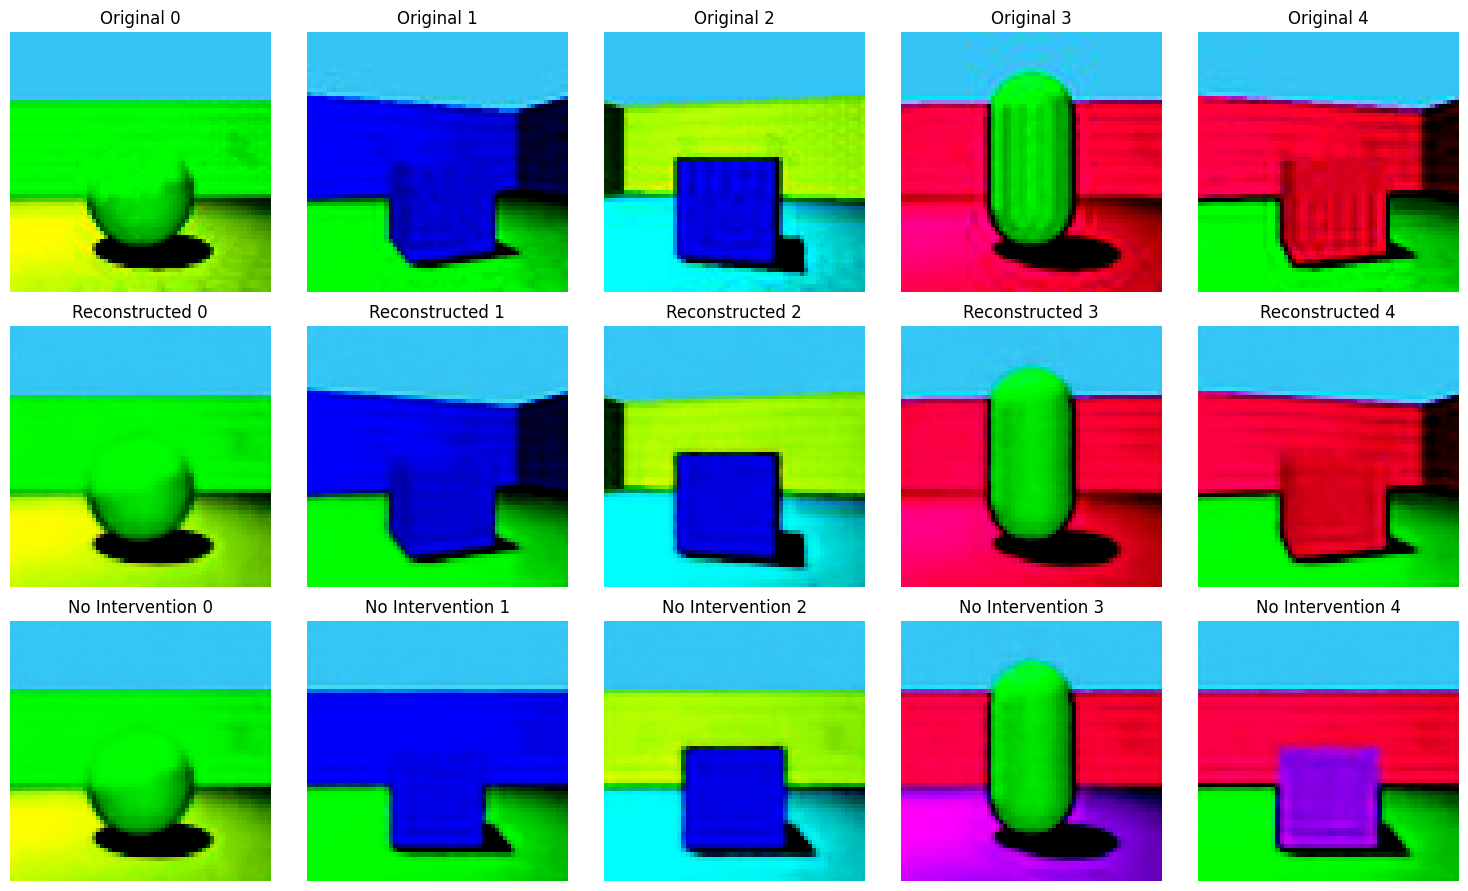

Inference complete. Input batch: torch.Size([64, 3, 64, 64])
Labels: [[-0.5555556  -0.3333333  -0.3333333   0.42857122  0.33333334  0.        ]
 [-0.1111111   0.33333337  0.33333337  0.14285707 -1.         -0.71428573]
 [ 0.11111116 -0.5555556   0.33333337  0.42857122 -1.          0.4285714 ]
 [ 1.          1.         -0.1111111   0.71428585  1.          0.14285713]
 [-0.1111111   1.          1.          0.42857122 -1.         -0.57142854]]
Labels with Intervention: [[-0.5043256  -0.30954394 -0.3256036   0.40929544  0.34524423 -0.00150506]
 [-0.08095752  0.31635433  0.3465837   0.12926775 -0.9861398  -0.00150506]
 [ 0.11256642 -0.5390882   0.36462888  0.41064996 -0.98768264 -0.00150506]
 [ 0.9315445   0.998163   -0.101507    0.6697424   1.0079805  -0.00150506]
 [-0.07953783  0.998163    0.87966675  0.41304588 -0.98396504 -0.00150506]]
Labels without Intervention: [[-0.5158285  -0.30822027 -0.3296013   0.4063501   0.34524423 -0.00150506]
 [-0.07917189  0.31341782  0.35262832  0.12926775

In [4]:
# 1. Setup Data
data = VAEDataset(**config["data_params"])
data.setup()
test_loader = data.test_dataloader()

# 2. Run Inference
with torch.no_grad():
    batch = next(iter(test_loader))
    real_imgs, labels = batch
    real_imgs = real_imgs.to(device)
    labels = labels.to(device)

    # Forward pass: [reconstruction, mu, log_var, (optional) concepts]
    results_interventions = model(real_imgs, interventions=labels)
    results_no_interventions = model(real_imgs)

    recons_intervention = results_interventions[0]
    recons_no_intervention = results_no_interventions[0]

    real_labels = labels
    labels_intervention = results_interventions[-1]
    labels_nointervention = results_no_interventions[-1]

# 3. Visualize
n = 5 # Number of images to show
plt.figure(figsize=(15, 9))
for i in range(n):
    # Original
    plt.subplot(3, n, i + 1)
    orig = real_imgs[i].cpu().permute(1, 2, 0).numpy()
    plt.imshow(orig.clip(0, 1))
    plt.title(f"Original {i}")
    plt.axis('off')

    # Reconstructed inervention
    plt.subplot(3, n, i + 1 + n)
    rec = recons[i].cpu().permute(1, 2, 0).numpy()
    plt.imshow(rec.clip(0, 1))
    plt.title(f"Reconstructed {i}")
    plt.axis('off')
    # reconstricted no intervention 
    plt.subplot(3, n, i + 1 + 2*n)  
    rec_no_int = recons_no_intervention[i].cpu().permute(1, 2, 0).numpy()
    plt.imshow(rec_no_int.clip(0, 1))
    plt.title(f"No Intervention {i}")
    plt.axis('off')

    

plt.tight_layout()
plt.show()

print(f"Inference complete. Input batch: {real_imgs.shape}")
# printinh the labels 
print(f"Labels: {labels[:n].cpu().numpy()}")
print(f"Labels with Intervention: {labels_intervention[:n].cpu().numpy()}")
print(f"Labels without Intervention: {labels_nointervention[:n].cpu().numpy()}")

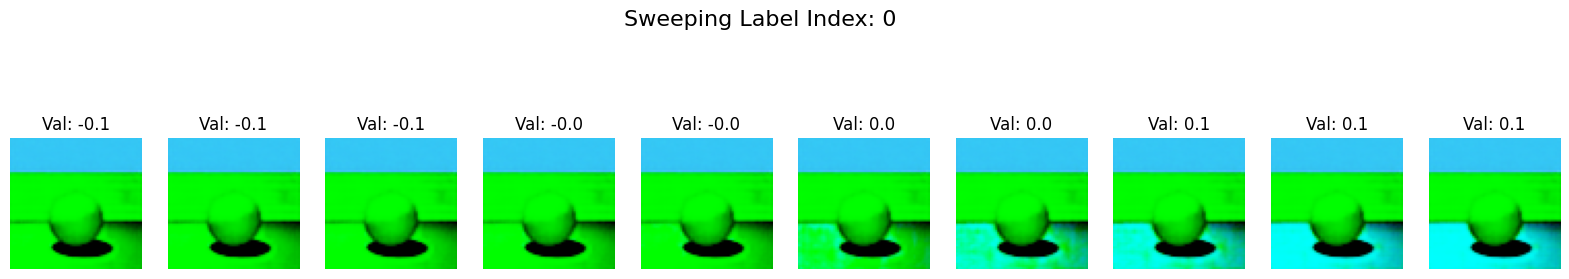

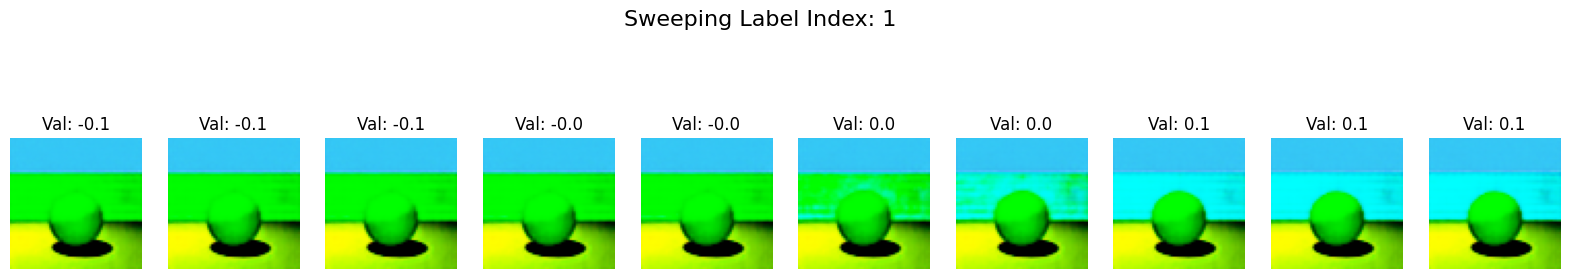

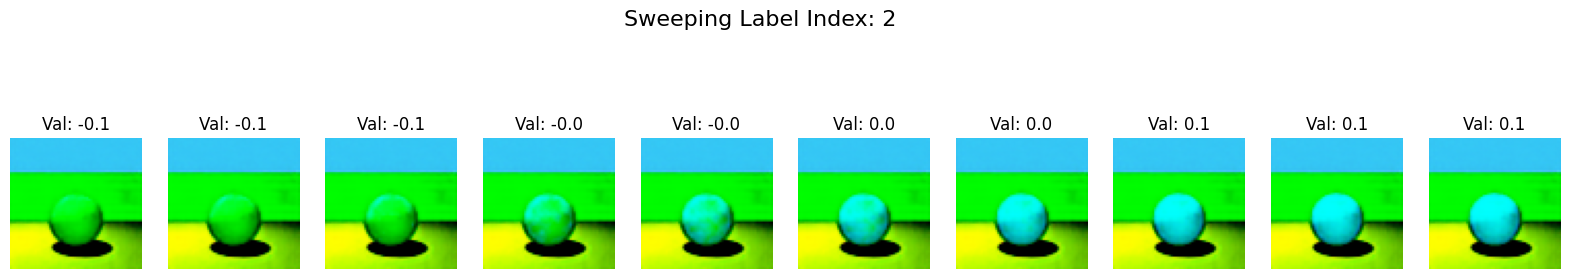

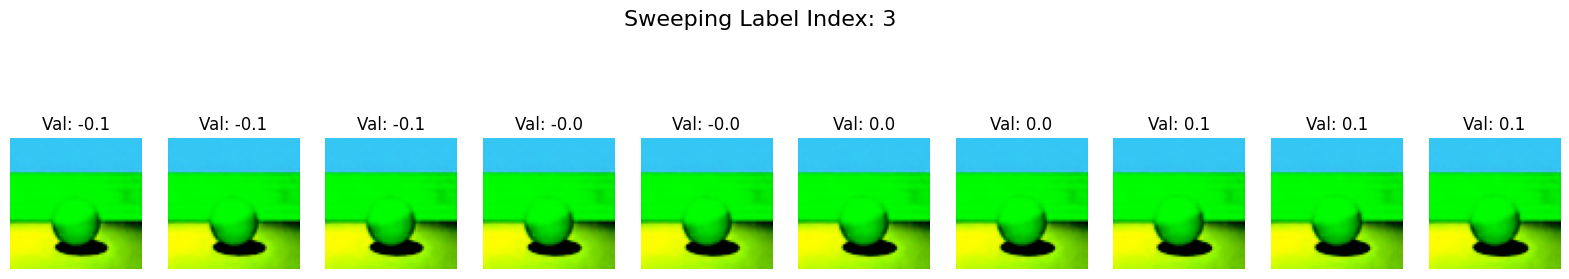

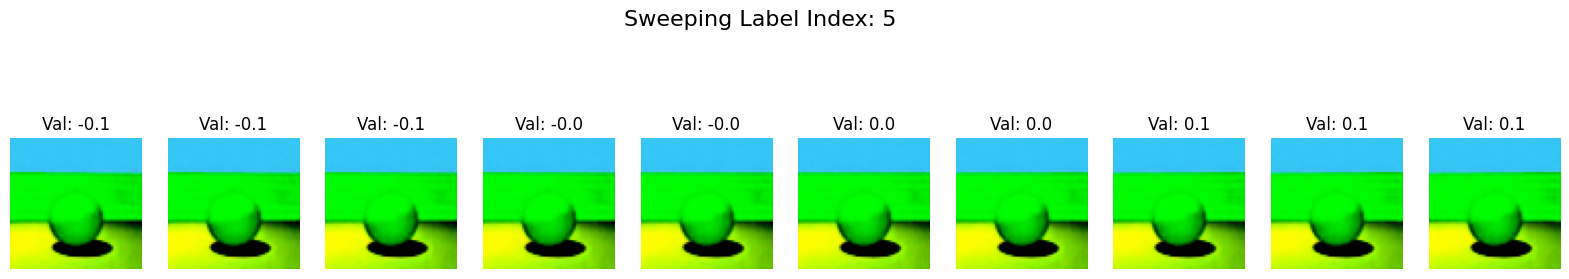

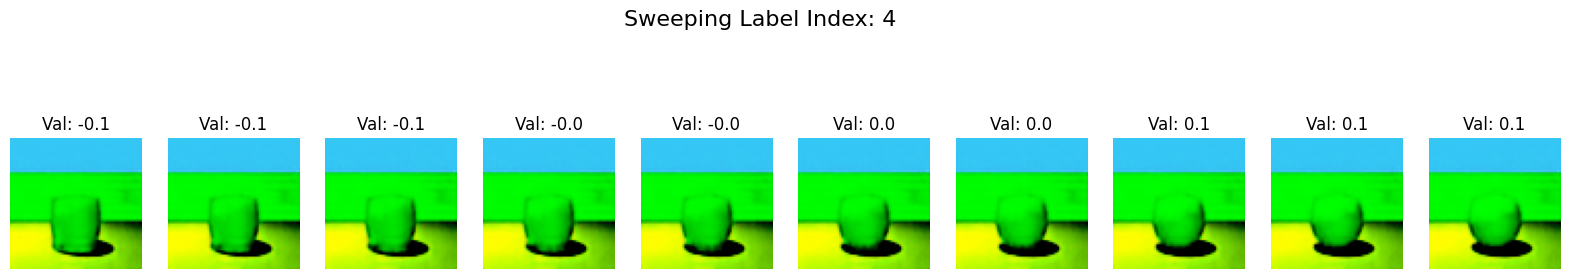

In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def label_sweep(model, test_loader, label_index, num_steps=10,min_val=-0.1,max_val=0.1):
    model.eval()
    
    # 1. Get a single sample
    real_imgs, labels = next(iter(test_loader))
    img = real_imgs[0:1].to(device)
    base_labels = labels[0:1].to(device)
    # 2. Create a range of values from -4 to 4
    sweep_values = torch.linspace(min_val, max_val, num_steps)
    
    # 3. Generate reconstructions
    plt.figure(figsize=(20, 4))
    
    with torch.no_grad():
        for i, val in enumerate(sweep_values):
            # Clone the original labels and intervene on the specific index
            intervened_labels = base_labels.clone()
            intervened_labels[0, label_index] = val
            
            # Forward pass
            results = model(img, interventions=intervened_labels)
            recon = results[0][0].cpu().permute(1, 2, 0).numpy()
            
            # Plot
            plt.subplot(1, num_steps, i + 1)
            plt.imshow(np.clip(recon, 0, 1))
            plt.title(f"Val: {val:.1f}")
            plt.axis('off')
            
    plt.suptitle(f"Sweeping Label Index: {label_index}", fontsize=16)
    plt.show()

# --- RUN THE SWEEP ---
# Change 'label_index' to see different features change
label_sweep(model, test_loader, label_index=0, num_steps=10)
label_sweep(model, test_loader, label_index=1, num_steps=10)
label_sweep(model, test_loader, label_index=2, num_steps=10)
label_sweep(model, test_loader, label_index=3, num_steps=10)
label_sweep(model, test_loader, label_index=5, num_steps=10)
label_sweep(model, test_loader, label_index=4, num_steps=10)





In [6]:
import gradio as gr
import torch
import numpy as np
from PIL import Image

# 1. SETUP: Prepare your sample data
model.eval()
real_imgs, labels = next(iter(test_loader))
# Keep one base image and one base label vector on the device
BASE_IMG = real_imgs[0:1].to(device)
BASE_LABELS = labels[0:1].to(device)

def intervene(val0, val1, val2, val3, val4, val5):
    """
    This function is called whenever ANY slider moves.
    It collects all slider values and runs the model.
    """
    with torch.no_grad():
        # Clone the original labels
        intervened_labels = BASE_LABELS.clone()
        
        # Update the labels based on current slider values
        # (Assuming your indices are 0 through 5 based on your code)
        intervened_labels[0, 0] = val0
        intervened_labels[0, 1] = val1
        intervened_labels[0, 2] = val2
        intervened_labels[0, 3] = val3
        intervened_labels[0, 4] = val4
        intervened_labels[0, 5] = val5
        
        # Run inference
        results = model(BASE_IMG, interventions=intervened_labels)
        
        
        # Process output (assumes results[0][0] is the reconstructed image)
        recon = results[0][0].cpu().permute(1, 2, 0).numpy()
        recon = np.clip(recon, 0, 1)

        img = Image.fromarray((recon * 255).astype(np.uint8))

        big_img = img.resize((256, 256), resample=Image.Resampling.NEAREST)
        
        # Convert to 0-255 format for Gradio
        return big_img

# 2. BUILD UI
with gr.Blocks() as demo:
    gr.Markdown("## Concept Intervention Slider Panel")
    
    with gr.Row():
        with gr.Column(scale=1):
            # Create a list to hold our slider objects
            sliders = []
            for i in range(6):
                s = gr.Slider(
                    minimum=-1.0, 
                    maximum=1.0, 
                    value=float(BASE_LABELS[0, i]), 
                    step=0.01, 
                    label=f"Label Index {i}"
                )
                sliders.append(s)
        
        with gr.Column(scale=5):
            output_display = gr.Image(label="Model Reconstruction",
                                      height= 300,
                                      width=300)

    # Link all sliders to the function
    # When any slider changes, 'intervene' runs with values from ALL sliders
    for s in sliders:
        s.change(
            fn=intervene, 
            inputs=sliders, 
            outputs=output_display
        )
demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [7]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_comparative_stats(model, test_loader):
    model.eval()
    all_pred_concepts = []
    all_real_labels = []

    print("Running inference on full dataset...")
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            
            # Forward pass
            # CBMVAE usually returns: [recons, mu, log_var, pred_concepts]
            # Adjust the index if your model's return signature is different
            results = model(images, interventions=labels.to(device))
            
            # 1. Capture Predicted Concepts (the bottleneck output)
            # Assuming results[3] is the predicted concept vector
            if len(results) > 3:
                pred_c = results[-1] 
                all_pred_concepts.append(pred_c.cpu().numpy())
            
            # 2. Capture Real Labels (ground truth)
            all_real_labels.append(labels.cpu().numpy())

    # Stack data
    all_real = np.vstack(all_real_labels)
    
    # Create the Comparison Table
    stats_summary = []
    
    # We use Ground Truth for the main stats
    for i in range(all_real.shape[1]):
        row = {
            'Label': f"Concept {i}",
            'Real Mean': np.mean(all_real[:, i]),
            'Real Min': np.min(all_real[:, i]),
            'Real Max': np.max(all_real[:, i]),
        }
        
        # Add Predicted stats if they were captured
        if all_pred_concepts:
            all_pred = np.vstack(all_pred_concepts)
            row['Pred Mean'] = np.mean(all_pred[:, i])
            row['Pred Min'] = np.min(all_pred[:, i])
            row['Pred Max'] = np.max(all_pred[:, i])
            # Accuracy/Error proxy: Mean Absolute Error
            row['MAE'] = np.mean(np.abs(all_real[:, i] - all_pred[:, i]))
            
        stats_summary.append(row)
    
    return pd.DataFrame(stats_summary), all_real, (all_pred if all_pred_concepts else None)

# --- Execute Comparison ---
comparison_df, real_data, pred_data = compute_comparative_stats(model, test_loader)

print("\n======= Comparison: Real vs. Predicted Labels =======")
display(comparison_df.round(4))

Running inference on full dataset...

======= Comparison: Real vs. Predicted Labels =======


,Label,Real Mean,Real Min,Real Max,Pred Mean,Pred Min,Pred Max,MAE
0,Concept 0,-0.0045,-1.0,1.0,0.0283,-0.8235,0.9697,0.0510
1,Concept 1,0.0019,-1.0,1.0,0.0312,-0.8672,0.9982,0.0439
2,Concept 2,0.0016,-1.0,1.0,0.0084,-0.9353,0.9108,0.0404
3,Concept 3,0.0024,-1.0,1.0,-0.0293,-0.9898,0.8715,0.0435
4,Concept 4,0.0035,-1.0,1.0,0.0169,-0.9987,1.0324,0.0136
5,Concept 5,-0.0004,-1.0,1.0,-0.0015,-0.0015,-0.0015,0.5343


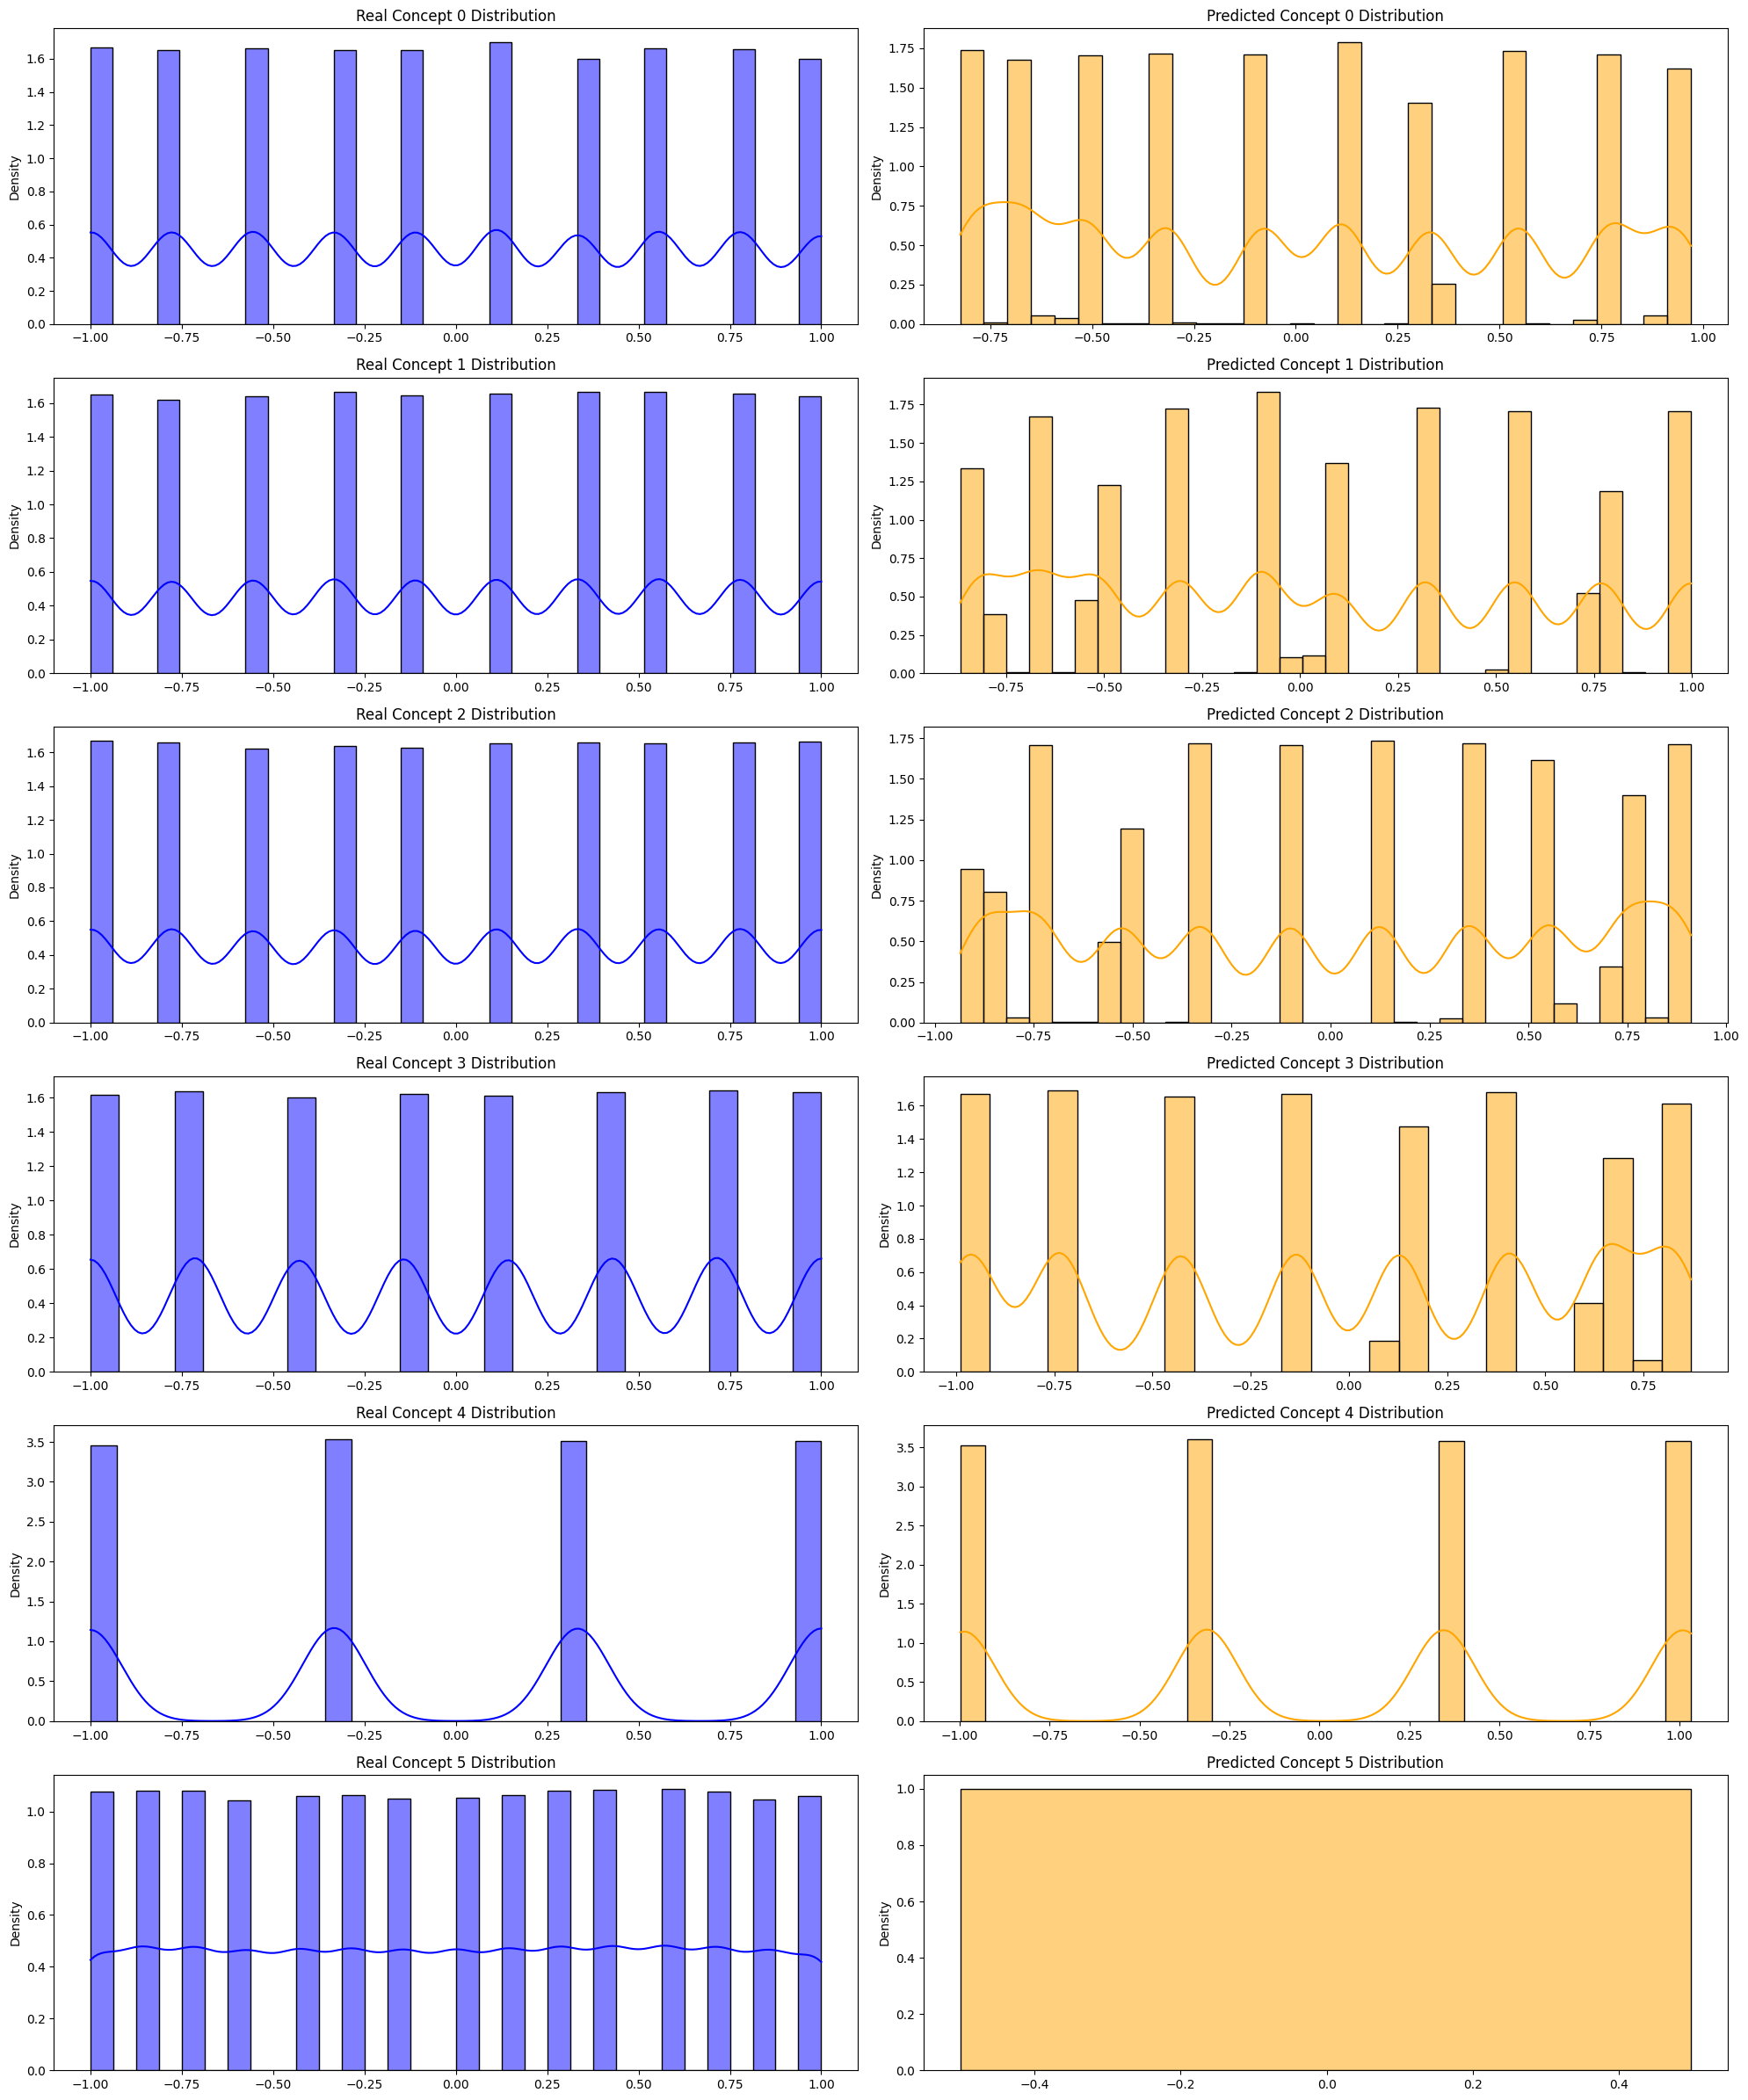

In [8]:
#priting the distibution of all concepts
import seaborn as sns
def plot_concept_distributions(real_data, pred_data=None):
    num_concepts = real_data.shape[1]
    plt.figure(figsize=(20, 4 * num_concepts))
    
    for i in range(num_concepts):
        plt.subplot(num_concepts, 2, 2*i + 1)
        sns.histplot(real_data[:, i], kde=True, color='blue', stat='density')
        plt.title(f"Real Concept {i} Distribution")
        
        if pred_data is not None:
            plt.subplot(num_concepts, 2, 2*i + 2)
            sns.histplot(pred_data[:, i], kde=True, color='orange', stat='density')
            plt.title(f"Predicted Concept {i} Distribution")
    
    plt.tight_layout()
    plt.show()
plot_concept_distributions(real_data, pred_data)

Searching for images with Concept 1 = 0...
No images found with Concept 1 = 0.
Searching for images with Concept 1 = 1...


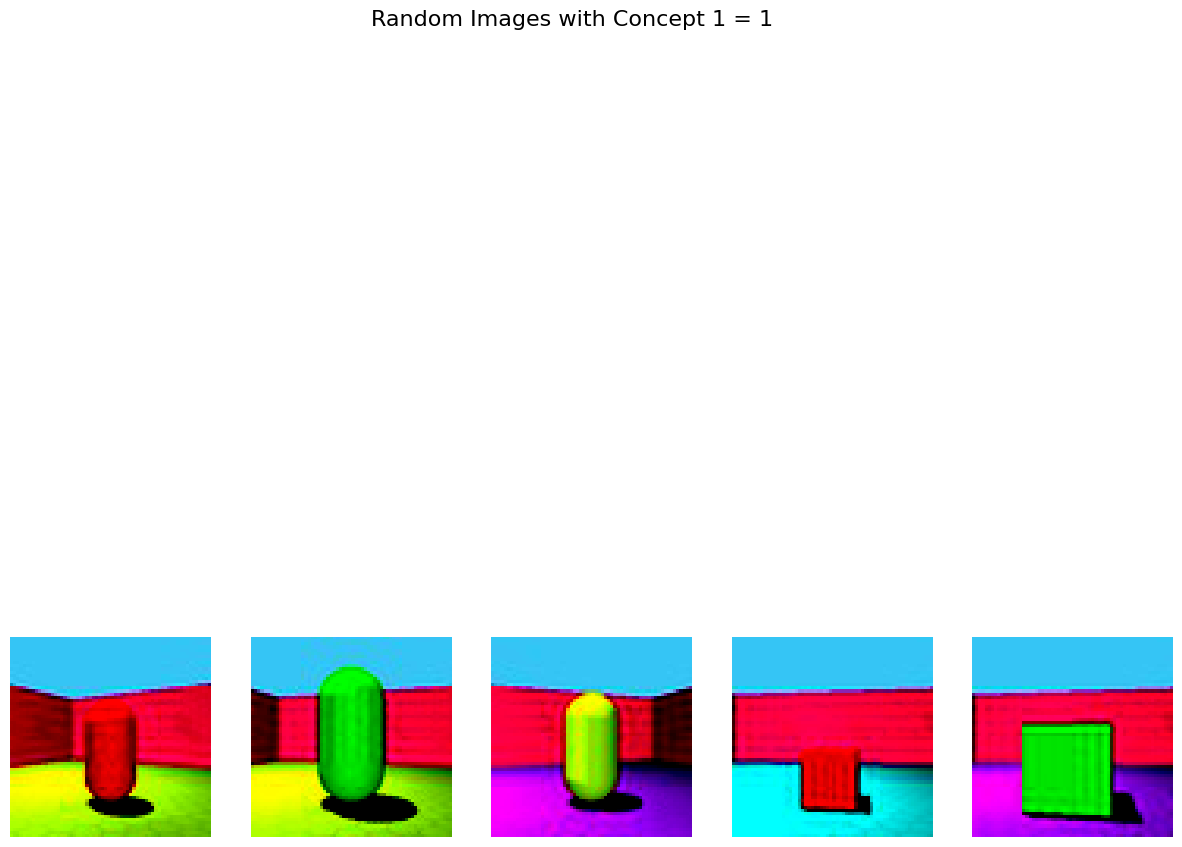

In [9]:
# pltting random pictures from the dataset where the concept is 1 
import random
def plot_random_concept_images(test_loader, concept_index, concept_value, num_images=5 ):
    model.eval()
    selected_images = []
    selected_labels = []

    print(f"Searching for images with Concept {concept_index} = {concept_value}...")
    
    # Gather images matching the concept criteria
    with torch.no_grad():
        for images, labels in test_loader:
            mask = (labels[:, concept_index] - concept_value).abs() < 1e-1
            if mask.any():
                selected_images.append(images[mask])
                selected_labels.append(labels[mask])
    
    if not selected_images:
        print(f"No images found with Concept {concept_index} = {concept_value}.")
        return
    
    selected_images = torch.cat(selected_images)
    selected_labels = torch.cat(selected_labels)
    
    # Randomly sample images to display
    num_to_display = min(num_images, selected_images.size(0))
    indices = random.sample(range(selected_images.size(0)), num_to_display)
    
    plt.figure(figsize=(15, 3 * num_to_display))
    for i, idx in enumerate(indices):
        img = selected_images[idx].cpu().permute(1, 2, 0).numpy()
        label = selected_labels[idx].cpu().numpy()
        
        plt.subplot(1, num_to_display, i + 1)
        plt.imshow(np.clip(img, 0, 1))
        #plt.title(f"Labels: {label}")
        plt.axis('off')
    
    plt.suptitle(f"Random Images with Concept {concept_index} = {concept_value}", fontsize=16)
    plt.show()

# Example: Plot images where Concept 0 is 1
plot_random_concept_images(test_loader, concept_index=1, concept_value=0, num_images=5)
plot_random_concept_images(test_loader, concept_index=1, concept_value=1, num_images=5)


In [10]:
# printing all possible hues in the dataset 
def plot_all_hues(test_loader):
    model.eval()
    hues = set()

    print("Collecting all unique hue values from the dataset...")
    
    with torch.no_grad():
        for _, labels in test_loader:
            hue_values = labels[:, 4].cpu().numpy()  # Assuming hue is at index 4
            hues.update(hue_values.tolist())
    
    hues = sorted(hues)
    print(f"Found {len(hues)} unique hue values: {hues}")
    
    plt.figure(figsize=(15, 3))
    for i, hue in enumerate(hues):
        plt.subplot(1, len(hues), i + 1)
        plt.text(0.5, 0.5, f"Hue: {hue:.2f}", fontsize=12, ha='center', va='center')
        plt.axis('off')
    
    plt.suptitle("All Unique Hue Values in Dataset", fontsize=16)
    plt.show()